In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

# set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [9]:
# Roll Number: 102317248
# sum of digits = 1+0+2+3+1+7+2+4+8 = 28
# window_size = 28 % 10 + 8 = 16
WINDOW_SIZE = 16

# last 2 digits = 48
# prediction_horizon = 48 % 3 + 1 = 0 + 1 = 1
PREDICTION_HORIZON = 1

# first 3 digits = 102
# hidden_size = 102 % 16 + 8 = 6 + 8 = 14
HIDDEN_SIZE = 14

# last digit is 8 (even), so we implement custom RNN
print(f"Window Size: {WINDOW_SIZE}")
print(f"Prediction Horizon: {PREDICTION_HORIZON}")
print(f"Hidden Size: {HIDDEN_SIZE}")
print("Model: Custom RNN")

Window Size: 16
Prediction Horizon: 1
Hidden Size: 14
Model: Custom RNN


In [10]:
file_path = '/kaggle/input/datasets/shenba/time-series-datasets/monthly-beer-production-in-austr.csv'

df = pd.read_csv(file_path, parse_dates=['Month'], index_col='Month')

scaler = MinMaxScaler((0,1))
scaled_data = scaler.fit_transform(df.values)

print(scaled_data.shape)

(476, 1)


In [11]:
def create_sequences(data, window_size, horizon):
    """
    converts raw time series into input-output pairs.
    input: past 'window_size' steps
    output: future 'horizon' steps
    """
    xs, ys = [], []
    for i in range(len(data) - window_size - horizon + 1):
        x = data[i:(i + window_size)]
        y = data[(i + window_size):(i + window_size + horizon)]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

X, y = create_sequences(scaled_data, WINDOW_SIZE, PREDICTION_HORIZON)

# chronological split (no random shuffling for time series)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# convert to pytorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")


X_train shape: torch.Size([368, 16, 1]), y_train shape: torch.Size([368, 1, 1])
X_test shape: torch.Size([92, 16, 1]), y_test shape: torch.Size([92, 1, 1])


In [12]:
class CustomRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(CustomRNN, self).__init__()
        self.hidden_size = hidden_size
        
        # input to hidden weights
        self.W_ih = nn.Parameter(torch.Tensor(input_size, hidden_size))
        # hidden to hidden weights (recurrent)
        self.W_hh = nn.Parameter(torch.Tensor(hidden_size, hidden_size))
        # hidden bias
        self.b_h = nn.Parameter(torch.Tensor(hidden_size))
        
        # hidden to output weights
        self.W_ho = nn.Parameter(torch.Tensor(hidden_size, output_size))
        # output bias
        self.b_o = nn.Parameter(torch.Tensor(output_size))
        
        # initialize weights properly
        self.init_weights()
        
    def init_weights(self):
        stdv = 1.0 / math.sqrt(self.hidden_size)
        for weight in self.parameters():
            weight.data.uniform_(-stdv, stdv)

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_size)
        batch_size = x.size(0)
        seq_len = x.size(1)
        
        # initialize hidden state to zeros
        h_t = torch.zeros(batch_size, self.hidden_size).to(x.device)
        
        # process sequence step by step
        for t in range(seq_len):
            x_t = x[:, t, :]
            # h_t = tanh(x_t * W_ih + h_{t-1} * W_hh + b_h)
            h_t = torch.tanh(torch.matmul(x_t, self.W_ih) + torch.matmul(h_t, self.W_hh) + self.b_h)
            
        # final prediction using the last hidden state
        output = torch.matmul(h_t, self.W_ho) + self.b_o
        return output


In [13]:
class MLPBaseline(nn.Module):
    def __init__(self, input_size, window_size, hidden_size, output_size):
        super(MLPBaseline, self).__init__()
        # mlp flattens the sequence, losing temporal order
        self.fc1 = nn.Linear(input_size * window_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # flatten (batch, seq, features) -> (batch, seq * features)
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [14]:
class PrebuiltLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PrebuiltLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # lstm returns output and (hidden, cell) states
        out, _ = self.lstm(x)
        # use the last output
        out = self.fc(out[:, -1, :])
        return out

class SimpleTransformer(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_heads=2):
        super(SimpleTransformer, self).__init__()
        # project input to hidden_size
        self.input_proj = nn.Linear(input_size, hidden_size)
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_size, nhead=num_heads, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.input_proj(x)
        out = self.transformer(x)
        # pool over the sequence
        out = out.mean(dim=1)
        out = self.fc(out)
        return out

# ==== cell 8: training setup ====
def train_model(model, X_train, y_train, epochs=100, lr=0.01):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X_train)
        
        # y_train shape might be (batch, horizon, 1), squeeze it
        loss = criterion(outputs, y_train.squeeze(-1))
        
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
        if (epoch+1) % 20 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}')
            
    return losses

def evaluate_model(model, X_test, y_test, scaler, name="Model"):
    model.eval()
    with torch.no_grad():
        preds = model(X_test)
        
    # inverse transform to get actual values
    # note: preds might be (batch, horizon)
    preds_np = preds.numpy()
    y_test_np = y_test.squeeze(-1).numpy()
    
    # if horizon > 1, we just evaluate the first prediction step for simplicity
    # or evaluate all. here we evaluate all steps flattened
    preds_inv = scaler.inverse_transform(preds_np.reshape(-1, 1))
    y_test_inv = scaler.inverse_transform(y_test_np.reshape(-1, 1))
    
    mse = mean_squared_error(y_test_inv, preds_inv)
    mae = mean_absolute_error(y_test_inv, preds_inv)
    rmse = math.sqrt(mse)
    
    print(f"--- {name} Metrics ---")
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    
    return preds_np, y_test_np, preds_inv, y_test_inv

In [15]:
print("Training Custom RNN...")
rnn_model = CustomRNN(input_size=1, hidden_size=HIDDEN_SIZE, output_size=PREDICTION_HORIZON)
rnn_losses = train_model(rnn_model, X_train, y_train, epochs=200, lr=0.005)
rnn_preds, rnn_y, rnn_preds_inv, rnn_y_inv = evaluate_model(rnn_model, X_test, y_test, scaler, "Custom RNN")


Training Custom RNN...
Epoch [20/200], Loss: 0.033803
Epoch [40/200], Loss: 0.028608
Epoch [60/200], Loss: 0.022027
Epoch [80/200], Loss: 0.017390
Epoch [100/200], Loss: 0.014964
Epoch [120/200], Loss: 0.014318
Epoch [140/200], Loss: 0.014139
Epoch [160/200], Loss: 0.013978
Epoch [180/200], Loss: 0.013842
Epoch [200/200], Loss: 0.013724
--- Custom RNN Metrics ---
MSE: 415.2829
MAE: 16.4543
RMSE: 20.3785


In [16]:
print("\nTraining MLP Baseline...")
mlp_model = MLPBaseline(input_size=1, window_size=WINDOW_SIZE, hidden_size=HIDDEN_SIZE, output_size=PREDICTION_HORIZON)
mlp_losses = train_model(mlp_model, X_train, y_train, epochs=200, lr=0.005)
mlp_preds, mlp_y, mlp_preds_inv, mlp_y_inv = evaluate_model(mlp_model, X_test, y_test, scaler, "MLP Baseline")



Training MLP Baseline...
Epoch [20/200], Loss: 0.031773
Epoch [40/200], Loss: 0.019738
Epoch [60/200], Loss: 0.013034
Epoch [80/200], Loss: 0.008741
Epoch [100/200], Loss: 0.007437
Epoch [120/200], Loss: 0.006748
Epoch [140/200], Loss: 0.006180
Epoch [160/200], Loss: 0.005723
Epoch [180/200], Loss: 0.005362
Epoch [200/200], Loss: 0.005078
--- MLP Baseline Metrics ---
MSE: 157.0880
MAE: 10.2742
RMSE: 12.5335


In [17]:
print("\nTraining Prebuilt LSTM...")
lstm_model = PrebuiltLSTM(input_size=1, hidden_size=HIDDEN_SIZE, output_size=PREDICTION_HORIZON)
lstm_losses = train_model(lstm_model, X_train, y_train, epochs=200, lr=0.005)
lstm_preds, lstm_y, lstm_preds_inv, lstm_y_inv = evaluate_model(lstm_model, X_test, y_test, scaler, "LSTM")

print("\nTraining Transformer...")
tf_model = SimpleTransformer(input_size=1, hidden_size=HIDDEN_SIZE, output_size=PREDICTION_HORIZON)
tf_losses = train_model(tf_model, X_train, y_train, epochs=200, lr=0.005)
tf_preds, tf_y, tf_preds_inv, tf_y_inv = evaluate_model(tf_model, X_test, y_test, scaler, "Transformer")



Training Prebuilt LSTM...
Epoch [20/200], Loss: 0.039434
Epoch [40/200], Loss: 0.021931
Epoch [60/200], Loss: 0.015988
Epoch [80/200], Loss: 0.014460
Epoch [100/200], Loss: 0.014044
Epoch [120/200], Loss: 0.013640
Epoch [140/200], Loss: 0.013271
Epoch [160/200], Loss: 0.012894
Epoch [180/200], Loss: 0.012433
Epoch [200/200], Loss: 0.011757
--- LSTM Metrics ---
MSE: 350.4374
MAE: 15.7599
RMSE: 18.7200

Training Transformer...
Epoch [20/200], Loss: 0.040164
Epoch [40/200], Loss: 0.016210
Epoch [60/200], Loss: 0.015071
Epoch [80/200], Loss: 0.014599
Epoch [100/200], Loss: 0.014489
Epoch [120/200], Loss: 0.014571
Epoch [140/200], Loss: 0.014516
Epoch [160/200], Loss: 0.014626
Epoch [180/200], Loss: 0.014678
Epoch [200/200], Loss: 0.014711
--- Transformer Metrics ---
MSE: 480.4347
MAE: 19.2915
RMSE: 21.9188


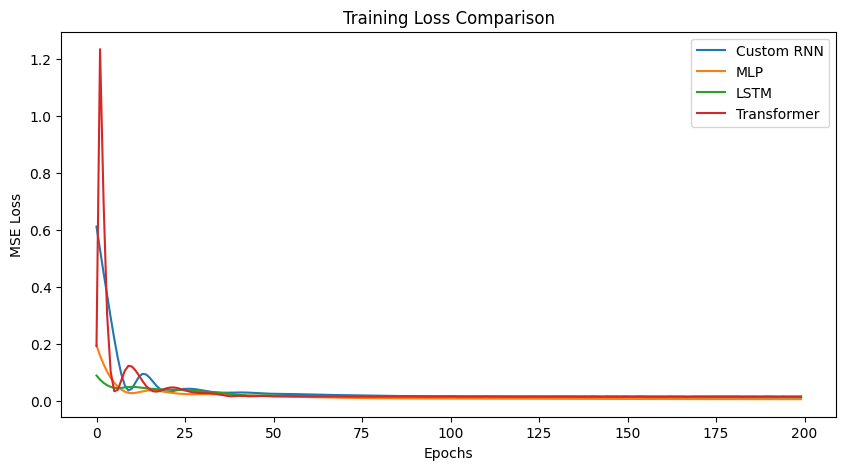

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(rnn_losses, label='Custom RNN')
plt.plot(mlp_losses, label='MLP')
plt.plot(lstm_losses, label='LSTM')
plt.plot(tf_losses, label='Transformer')
plt.title('Training Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

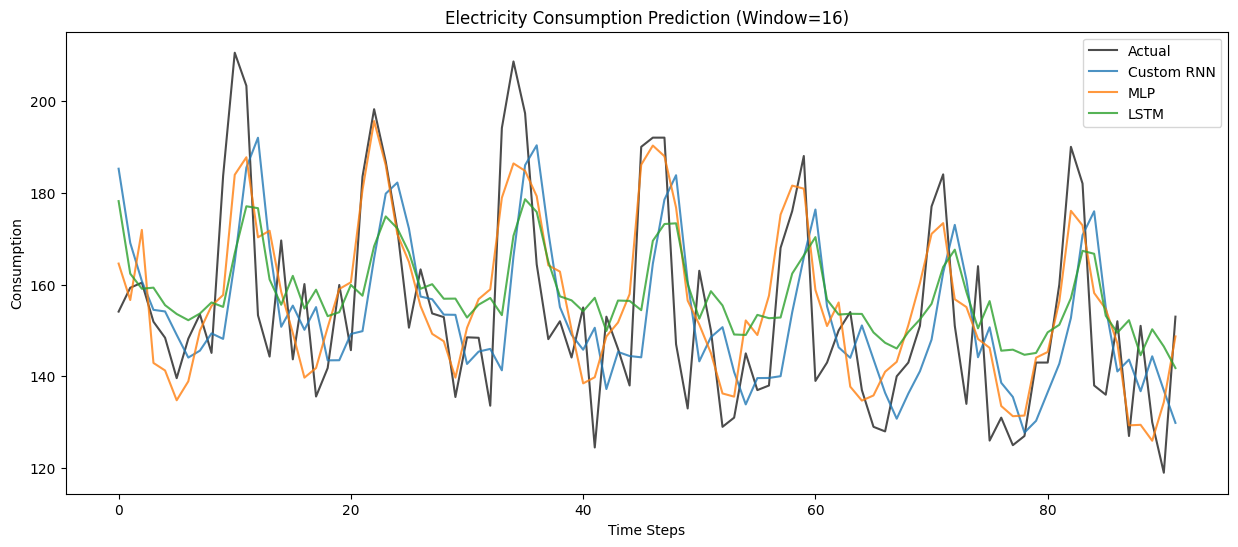

In [19]:
plt.figure(figsize=(15, 6))
# we plot the first step of the prediction horizon for visualization
plt.plot(rnn_y_inv[0::PREDICTION_HORIZON], label='Actual', color='black', alpha=0.7)
plt.plot(rnn_preds_inv[0::PREDICTION_HORIZON], label='Custom RNN', alpha=0.8)
plt.plot(mlp_preds_inv[0::PREDICTION_HORIZON], label='MLP', alpha=0.8)
plt.plot(lstm_preds_inv[0::PREDICTION_HORIZON], label='LSTM', alpha=0.8)
plt.title(f'Electricity Consumption Prediction (Window={WINDOW_SIZE})')
plt.xlabel('Time Steps')
plt.ylabel('Consumption')
plt.legend()
plt.show()

In [20]:
print("\n=== Ablation Study: Window Sizes ===")
ablation_windows = [WINDOW_SIZE // 2, WINDOW_SIZE, WINDOW_SIZE * 2]

for w in ablation_windows:
    if w <= 0: continue
    print(f"\nTesting Window Size: {w}")
    X_ab, y_ab = create_sequences(scaled_data, w, PREDICTION_HORIZON)
    train_sz = int(len(X_ab) * 0.8)
    X_ab_tr, X_ab_te = torch.tensor(X_ab[:train_sz], dtype=torch.float32), torch.tensor(X_ab[train_sz:], dtype=torch.float32)
    y_ab_tr, y_ab_te = torch.tensor(y_ab[:train_sz], dtype=torch.float32), torch.tensor(y_ab[train_sz:], dtype=torch.float32)
    
    ab_model = CustomRNN(input_size=1, hidden_size=HIDDEN_SIZE, output_size=PREDICTION_HORIZON)
    train_model(ab_model, X_ab_tr, y_ab_tr, epochs=150, lr=0.005)
    evaluate_model(ab_model, X_ab_te, y_ab_te, scaler, f"Custom RNN (Window={w})")



=== Ablation Study: Window Sizes ===

Testing Window Size: 8
Epoch [20/150], Loss: 0.016297
Epoch [40/150], Loss: 0.013986
Epoch [60/150], Loss: 0.013351
Epoch [80/150], Loss: 0.012750
Epoch [100/150], Loss: 0.011680
Epoch [120/150], Loss: 0.010864
Epoch [140/150], Loss: 0.010753
--- Custom RNN (Window=8) Metrics ---
MSE: 390.8465
MAE: 15.9028
RMSE: 19.7698

Testing Window Size: 16
Epoch [20/150], Loss: 0.035381
Epoch [40/150], Loss: 0.023047
Epoch [60/150], Loss: 0.015402
Epoch [80/150], Loss: 0.014557
Epoch [100/150], Loss: 0.013872
Epoch [120/150], Loss: 0.013122
Epoch [140/150], Loss: 0.012280
--- Custom RNN (Window=16) Metrics ---
MSE: 360.0334
MAE: 15.7957
RMSE: 18.9745

Testing Window Size: 32
Epoch [20/150], Loss: 0.030663
Epoch [40/150], Loss: 0.025690
Epoch [60/150], Loss: 0.019154
Epoch [80/150], Loss: 0.017015
Epoch [100/150], Loss: 0.016470
Epoch [120/150], Loss: 0.016003
Epoch [140/150], Loss: 0.015632
--- Custom RNN (Window=32) Metrics ---
MSE: 448.3366
MAE: 17.1338
RMS

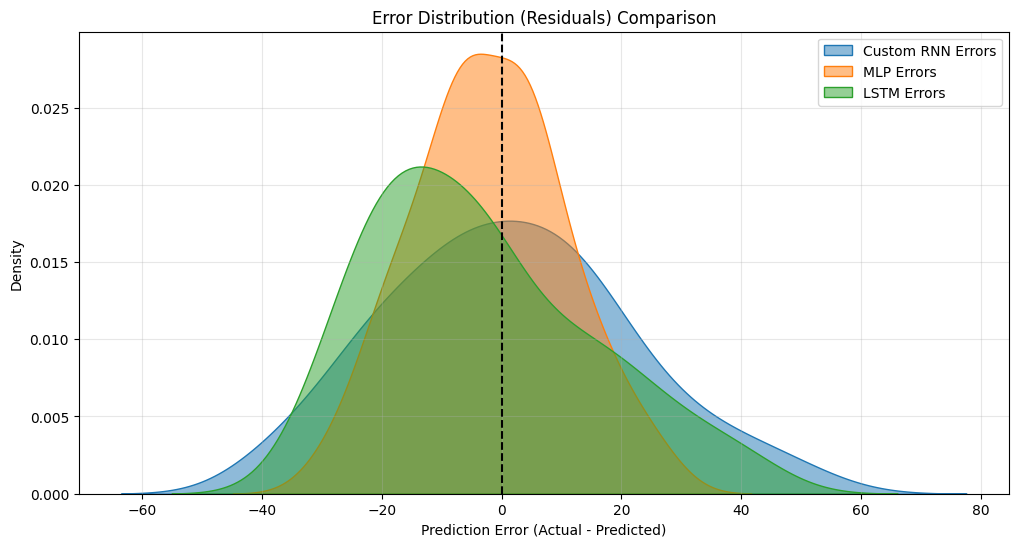

In [21]:
import seaborn as sns

# calculate errors
rnn_err = rnn_y_inv[0::PREDICTION_HORIZON] - rnn_preds_inv[0::PREDICTION_HORIZON]
mlp_err = mlp_y_inv[0::PREDICTION_HORIZON] - mlp_preds_inv[0::PREDICTION_HORIZON]
lstm_err = lstm_y_inv[0::PREDICTION_HORIZON] - lstm_preds_inv[0::PREDICTION_HORIZON]

plt.figure(figsize=(12, 6))
sns.kdeplot(rnn_err.flatten(), fill=True, label='Custom RNN Errors', alpha=0.5)
sns.kdeplot(mlp_err.flatten(), fill=True, label='MLP Errors', alpha=0.5)
sns.kdeplot(lstm_err.flatten(), fill=True, label='LSTM Errors', alpha=0.5)

plt.title('Error Distribution (Residuals) Comparison')
plt.xlabel('Prediction Error (Actual - Predicted)')
plt.ylabel('Density')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


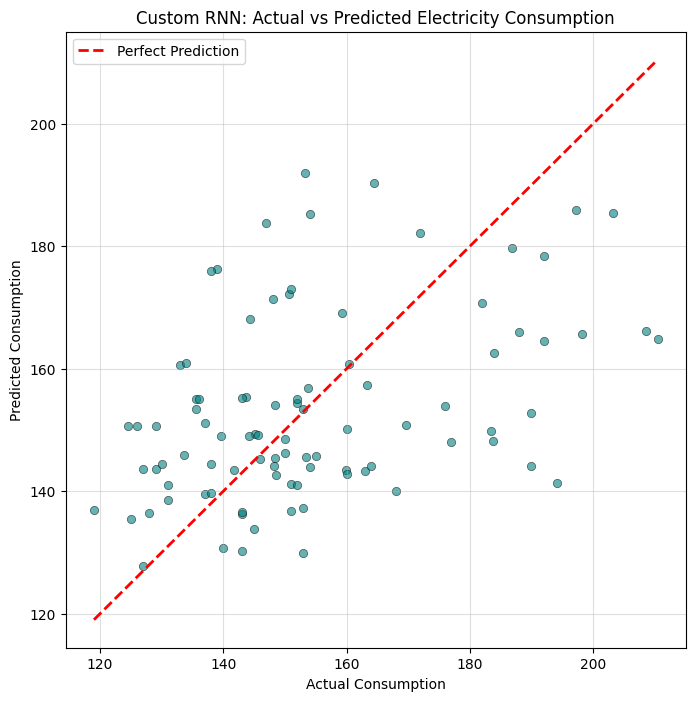

In [22]:
plt.figure(figsize=(8, 8))

# plot the custom RNN predictions
plt.scatter(rnn_y_inv[0::PREDICTION_HORIZON], rnn_preds_inv[0::PREDICTION_HORIZON], 
            alpha=0.6, color='teal', edgecolor='black', linewidth=0.5)

# plot the perfect prediction diagonal line
min_val = min(rnn_y_inv.min(), rnn_preds_inv.min())
max_val = max(rnn_y_inv.max(), rnn_preds_inv.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

plt.title('Custom RNN: Actual vs Predicted Electricity Consumption')
plt.xlabel('Actual Consumption')
plt.ylabel('Predicted Consumption')
plt.legend()
plt.grid(alpha=0.4)
plt.show()
